# CIL 2026 - Eigenfaces - SOLUTION

## Setup:
* Make sure you have installed numpy and matplotlib on your system (use pip3 install ...)
* Download the face images dataset (CroppedYaleExpr) from the moodle website.

notes: the dataset is a non-comercial, publically available dataset from [Yale University](http://cvc.cs.yale.edu/cvc/projects/yalefaces/yalefaces.html). Face cropping has been performed using MTCNN by [Zhang et al., 2016](https://arxiv.org/abs/1604.02878)

In [12]:
# you can also directly install packages from this Notebook:
# !pip3 install ...

In [13]:
%matplotlib inline

import os, sys

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [14]:
# First load data

#image_dir = "CroppedYaleExpr/"

# Using GDrive:
from google.colab import drive
drive.mount('/content/drive')
image_dir = "/content/drive/MyDrive/Tutorials/CroppedYaleExpr/"

files = sorted(os.listdir(image_dir))
n = len(files)
print("Loading " + str(n) + " images")

imgs = [np.load(image_dir + files[i]) for i in range(n)]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading 165 images


In [15]:
print(type(imgs[0]))
print(imgs[0].shape)

<class 'numpy.ndarray'>
(80, 80)


In [16]:
np.max(imgs[0])

np.float64(1.0)

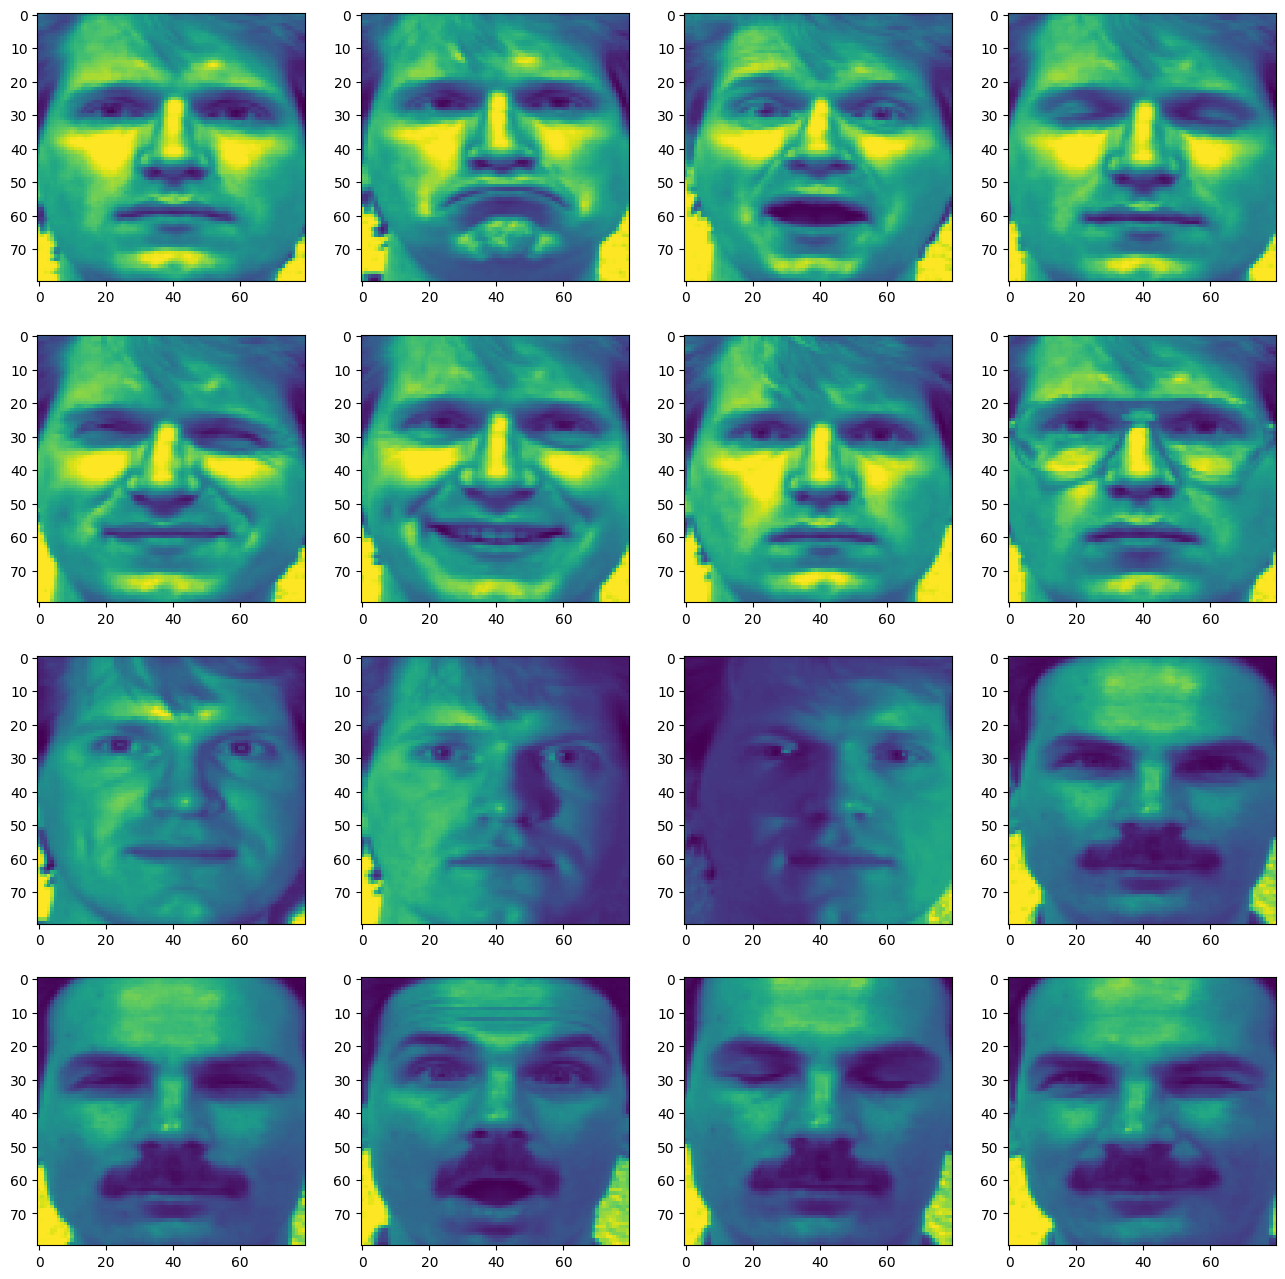

In [17]:
# Display some images
pcols = 4
prows = 4

fig = plt.figure(figsize=(16,16))
for i in range(0, pcols*prows):
    fig.add_subplot(prows, pcols, i+1)
    plt.imshow(imgs[i])

In [18]:
# TODO - Compute input Matrix X: n x d

img0 = imgs[0]
width, height = img0.shape
wh = width*height

X_list = [np.reshape(imgs[i], wh) for i in range(n)]
X = np.array(X_list)
print(X.shape)

(165, 6400)


In [19]:
# TODO - Subtract the mean image mX from input matrix X

mX = np.mean(X, axis=0)
print(mX.shape)
X = X - mX # broadcasting

(6400,)


In [20]:
mX

array([0.2595097 , 0.22824576, 0.18352957, ..., 0.48809319, 0.51808436,
       0.55491848])

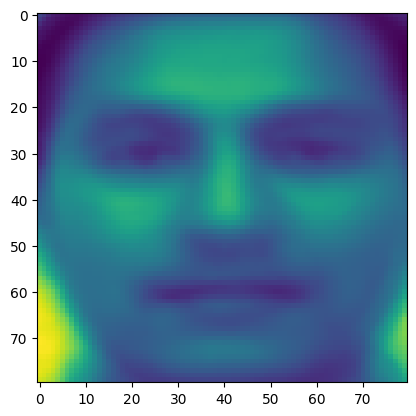

In [21]:
# TODO - Visualize the mean image

mX_2d = np.reshape(mX, (height, width))
plt.imshow(mX_2d)

(6400, 6400)


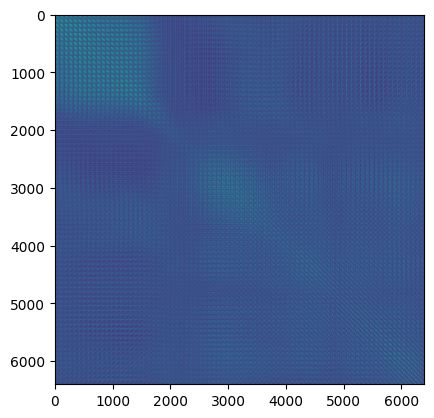

In [22]:
# TODO - compute covariance matrix: 1/n * X * X^T, if X is a d x n matrix

covariance = np.cov(X.T) # we transpose to get a d x n matrix required by np.cov
print(covariance.shape)
plt.imshow(covariance)

In [23]:
# TODO - Compute SVD of the covariance matrix

U, s, V = np.linalg.svd(covariance, full_matrices=True) # Sigma = U^T * diag(s) * V
U.shape, V.shape, s.shape

((6400, 6400), (6400, 6400), (6400,))

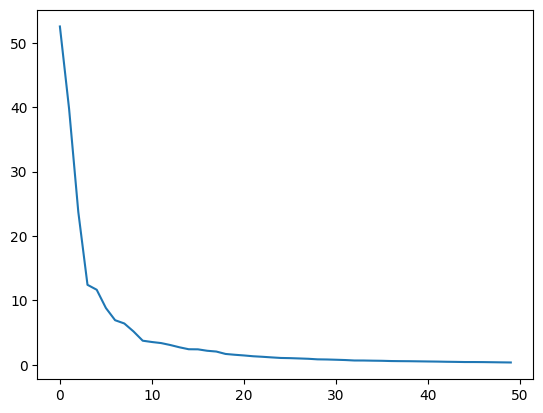

In [24]:
# TODO - Choose a good number (k) of eigenvectors << D
# hint: You might want to plot the eigenvalues for your decision

plt.plot(s[:50])
plt.show()

k = 20

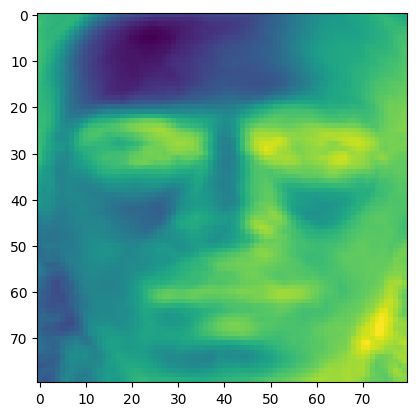

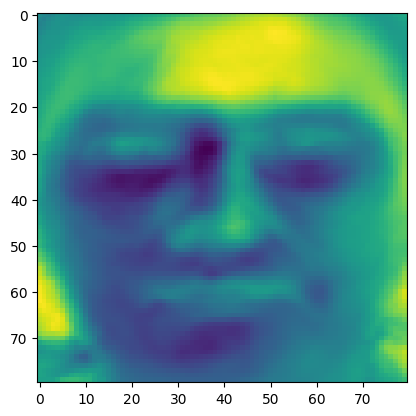

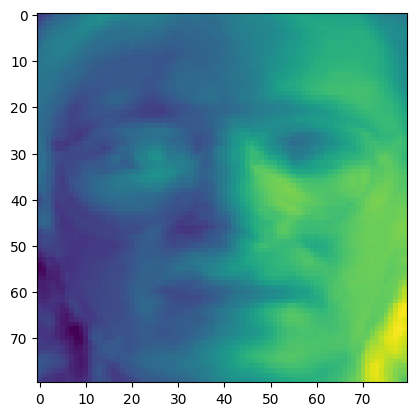

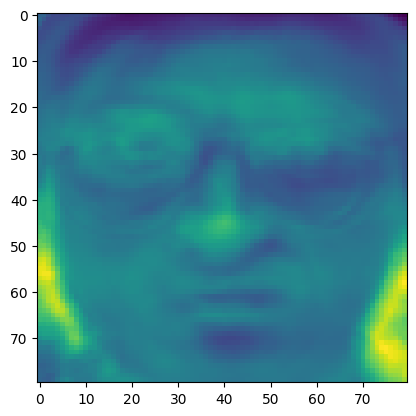

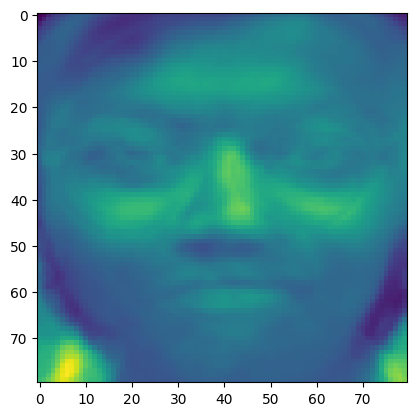

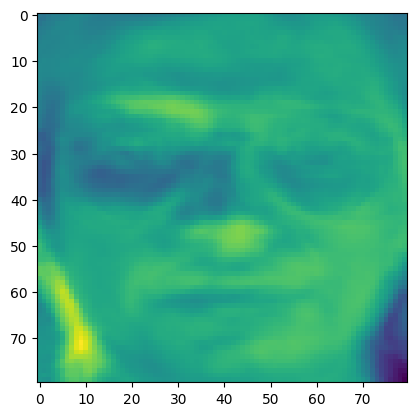

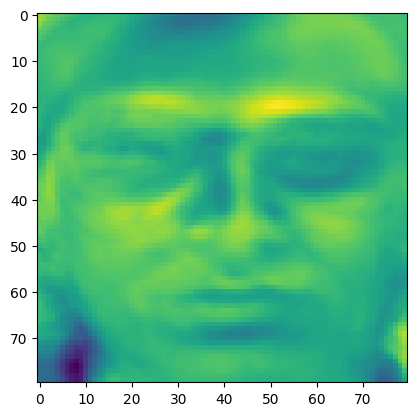

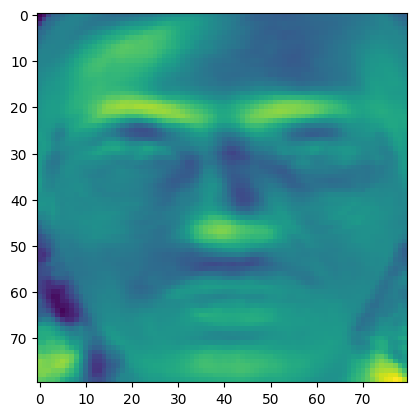

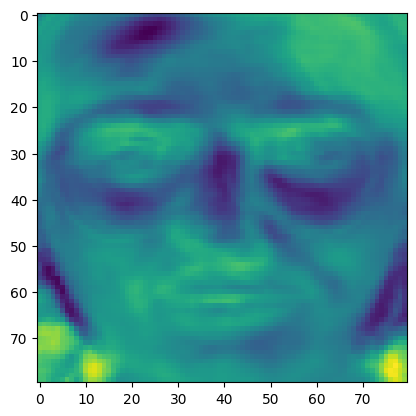

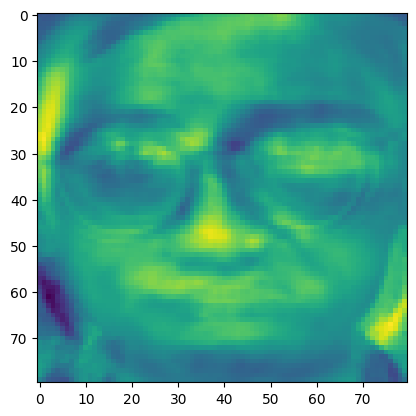

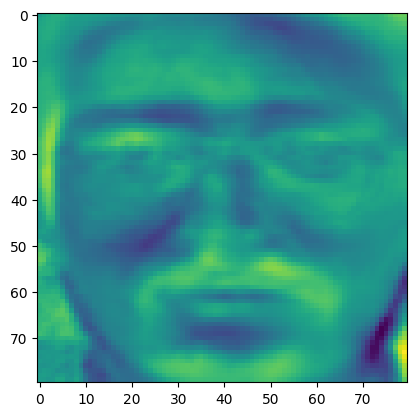

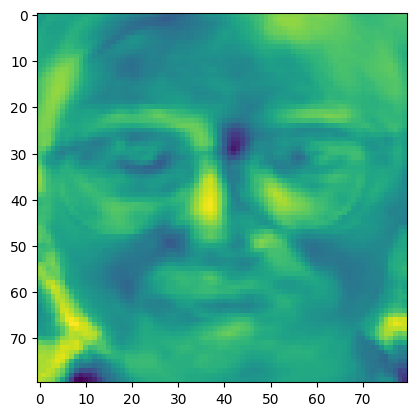

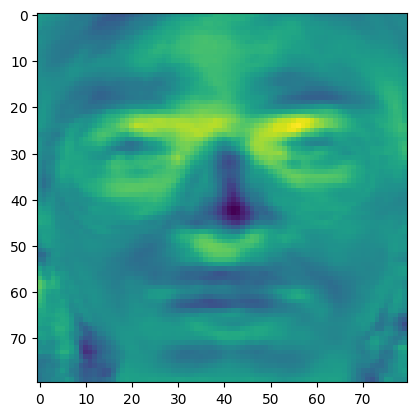

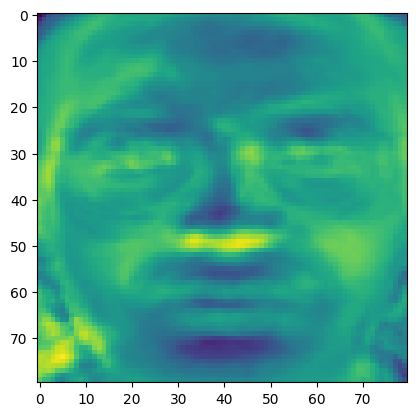

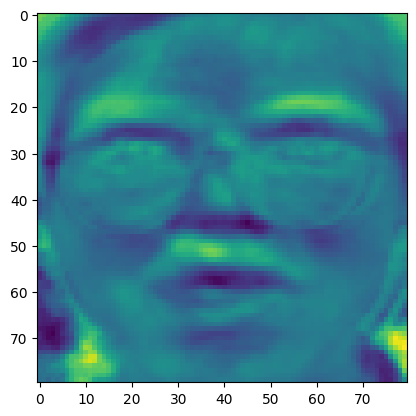

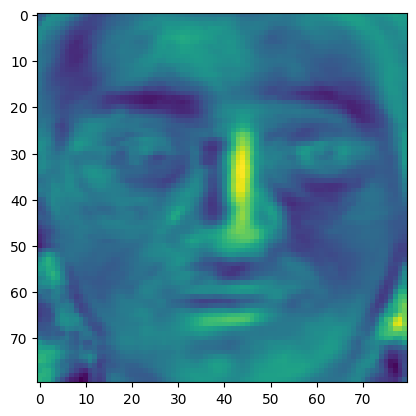

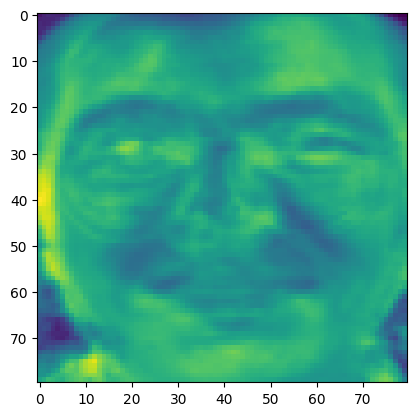

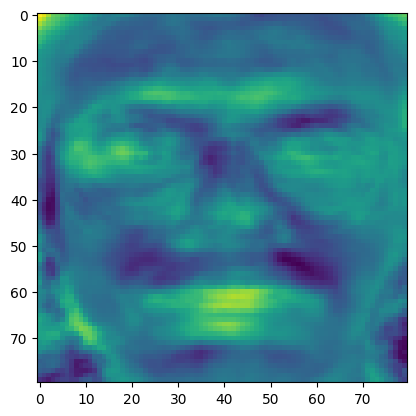

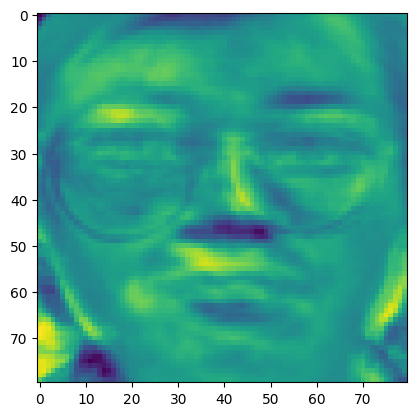

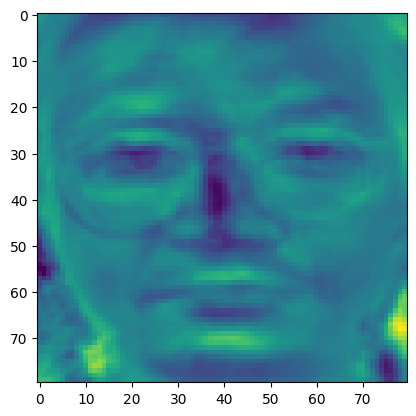

(1600, 80)

In [25]:
# TODO - Extract and visualize the eigenfaces which are represented by the eigenvectors (columns of matrix U)

list_eigenfaces = [np.reshape(U[:,i], (height, width)) for i in range(k)] # or np.array([0,1,2,3,4])
eigenfaces = np.reshape(np.asarray(list_eigenfaces), (k*height, width))
fig1 = plt.figure() # create a figure with the default size
# plt.imshow(eigenfaces)
for i in range(k):
  plt.imshow(list_eigenfaces[i])
  plt.show()

#fig1.savefig('eigenfaces.png', dpi = 1000)
eigenfaces.shape

In [26]:
# TODO - Build the reprojection Matrix (with the chosen rank constraints)

U_k = np.array([U[:, i] for i in range(k)])
U_k.shape

(20, 6400)

In [27]:
# TODO - Perform image compression with PCA keeping top K eigenvalues
Z = U_k.dot(X.T)
Z.shape

(20, 165)

In [28]:
# Image 10 has now been compressed from size 4000 to size k.
Z[:,10]

array([15.306136  ,  2.50483121,  8.12025262, -2.13507133, -4.14289032,
        1.63629595,  0.89443871,  2.74797791,  0.73962422, -1.03599925,
        0.12644711, -2.17958344,  0.13902992,  0.19027267,  0.71472709,
       -2.01829222,  0.45569172, -0.13843255, -0.98158215,  0.24612188])

In [29]:
# TODO - Perform image decompression (remember to add back the mean of the data)
X_bar = U_k.T.dot(Z).T  + mX
X_bar.shape

(165, 6400)

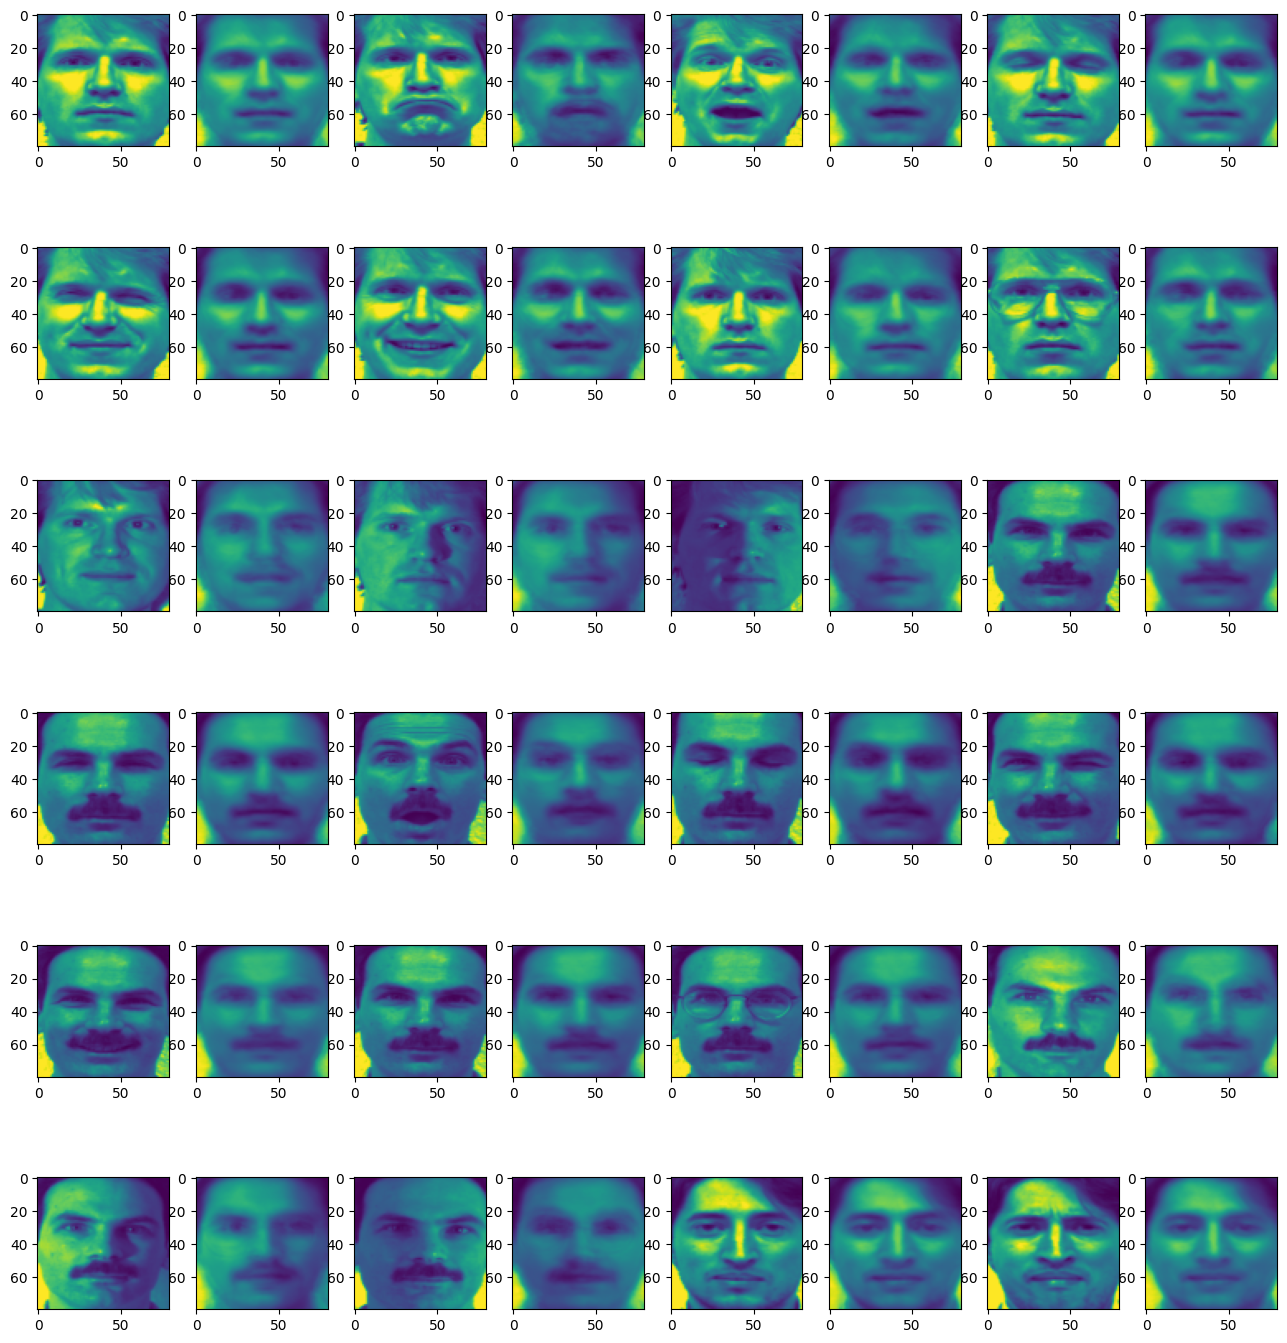

In [30]:
# TODO - Plot the original and decompressed image, and play around with k. How does the quality change?

# Display some images
pcols = 8
prows = 24

fig = plt.figure(figsize=(16,3*prows))
for i in range(0, prows):
    org_img = np.reshape(X[i,:] + mX, (height, width))
    fig.add_subplot(prows, pcols, (2*i)+1)
    plt.imshow(org_img)

    rec_img = np.reshape(X_bar[i,:] + mX, (height, width))
    fig.add_subplot(prows, pcols, (2*i)+2)
    plt.imshow(rec_img)

## (Bonus) Tucker Decomposition

This presents an additional extension of PCA for the interested reader and is not relevant for the exam.

#### You might have noticed that the dataset includes multiple images of the same subject while being captured in another condition. In total, we have 15 subjects and 11 conditions _{'normal': '00', 'sad': '01', 'surprised': '02', 'sleepy': '03', 'wink': '04', 'happy': '05', 'noglasses': '06', 'glasses': '07', 'centerlight': '08', 'leftlight': '09', 'rightlight': '10'}_. The filename encodes this information as ```{subjectID}\_{conditionID}.npy```.

#### Instead of performing PCA on the data-matrix $X \in \mathbb{R}^{D \times N}$ one could think about exploiting this information and perform PCA on a data-tensor $T \in \mathbb{R}^{D \times S \times C}$ instead, we refer to the dimensions of the tensor as _modes_. In this case, a three-mode extension of PCA is required and can be achieved with the [Tucker Decomposition](https://en.wikipedia.org/wiki/Tucker_decomposition). This can be used to trade the reconstruction quality in one mode for another.

#### In this exercise, we will use [Tensorly](http://tensorly.org/stable/index.html), an open-source Tensor-Library that implements the core Tensor operations and decompositions (pip3 install tensorly).

In [32]:
!pip install tensorly
import tensorly as tl
from tensorly.decomposition import tucker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 55.7 MB/s eta 0:00:00


#### Start by organising your data into the Tensor $T \in \mathbb{R}^{D \times S \times C}$.

In [33]:
# TODO - Fill the given tensor placeholder
T = np.zeros((height*width, 15, 11)) # flattened image size, #subjects, #conditions

for s in range(15):
    for c in range(11):
        filename = f'{s:02}_{c:02}.npy'
        T[:, s, c] = np.reshape(np.load(os.path.join(image_dir, filename)), 80*80)

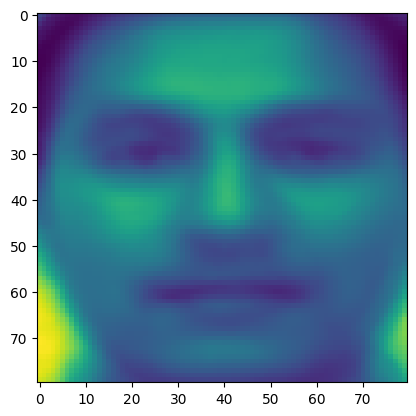

In [34]:
# TODO - center the Tensor
mT = np.mean(T, axis=(1,2))
T = T - np.tile(mT.reshape((-1,1,1)), (1, 15, 11)) # broadcasting

# visualize mean face
plt.imshow(mT.reshape((height, width)))
plt.show()

#### The Tucker Decomposition gives us a core tensor $\mathcal{T}_c \in \mathbb{R}^{D \times S \times C}$ containing the 1-mode, 2-mode, and 3-mode singular values of T (the equivalent of the singular value matrix in SVD) and factors for each mode $U^{(1)} \in \mathbb{R}^{D \times D}$, $U^{(2)} \in \mathbb{R}^{S \times S}$, $U^{(3)} \in \mathbb{R}^{C \times C}$ (corresponding to the eigenvectors):

$T = \mathcal{T}_c \times_1 U^{(1)} \times_2 U^{(2)} \times_3 U^{(3)}$

#### , where $\times_m$ describes the m-mode product (you can think of this as a matrix multiplication along the specific axis of the tensor)

#### The Tensorly function lets us directly define rank constraints for the decomposition (tucker_rank $= [k_D, k_S, k_C]$). We can introduce a rank constraint per mode. Resulting into factors of the form $U^{(1)} \in \mathbb{R}^{k_D \times D}$, $U^{(2)} \in \mathbb{R}^{k_S \times S}$, $U^{(3)} \in \mathbb{R}^{k_C \times C}$

#### A 'fully' reconstructable decomposition can be achieved by choosing the maximum tucker rank (80*80, 15, 11). For our experiments, we will use a rank constraint of 100 for the first mode, the image dimensionality, and play around with the more interesting 2-mode and 3-mode:

#### First, let us consider the maximum rank for the second and third factors:

In [35]:
# rank constraints
tucker_rank = [100, 15, 11]

# TODO - perform a Tucker decomposition
# Hint: have a look at tensorly.decomposition import tucker
core, (factors_d, factors_sub, factors_con) = tucker(T, rank=tucker_rank)

# TODO- perform the reconstruction
# Hint: have a look at tensorly.tenalg.mode_dot or tensorly.tucker_to_tensor
T_bar = tl.tenalg.mode_dot(tl.tenalg.mode_dot(tl.tenalg.mode_dot(
    core, factors_d, 0), factors_sub, 1), factors_con, 2)

#### Plotting random subjects with random conditions, we see that the reconstructed Tensor is close to the subject and the condition.

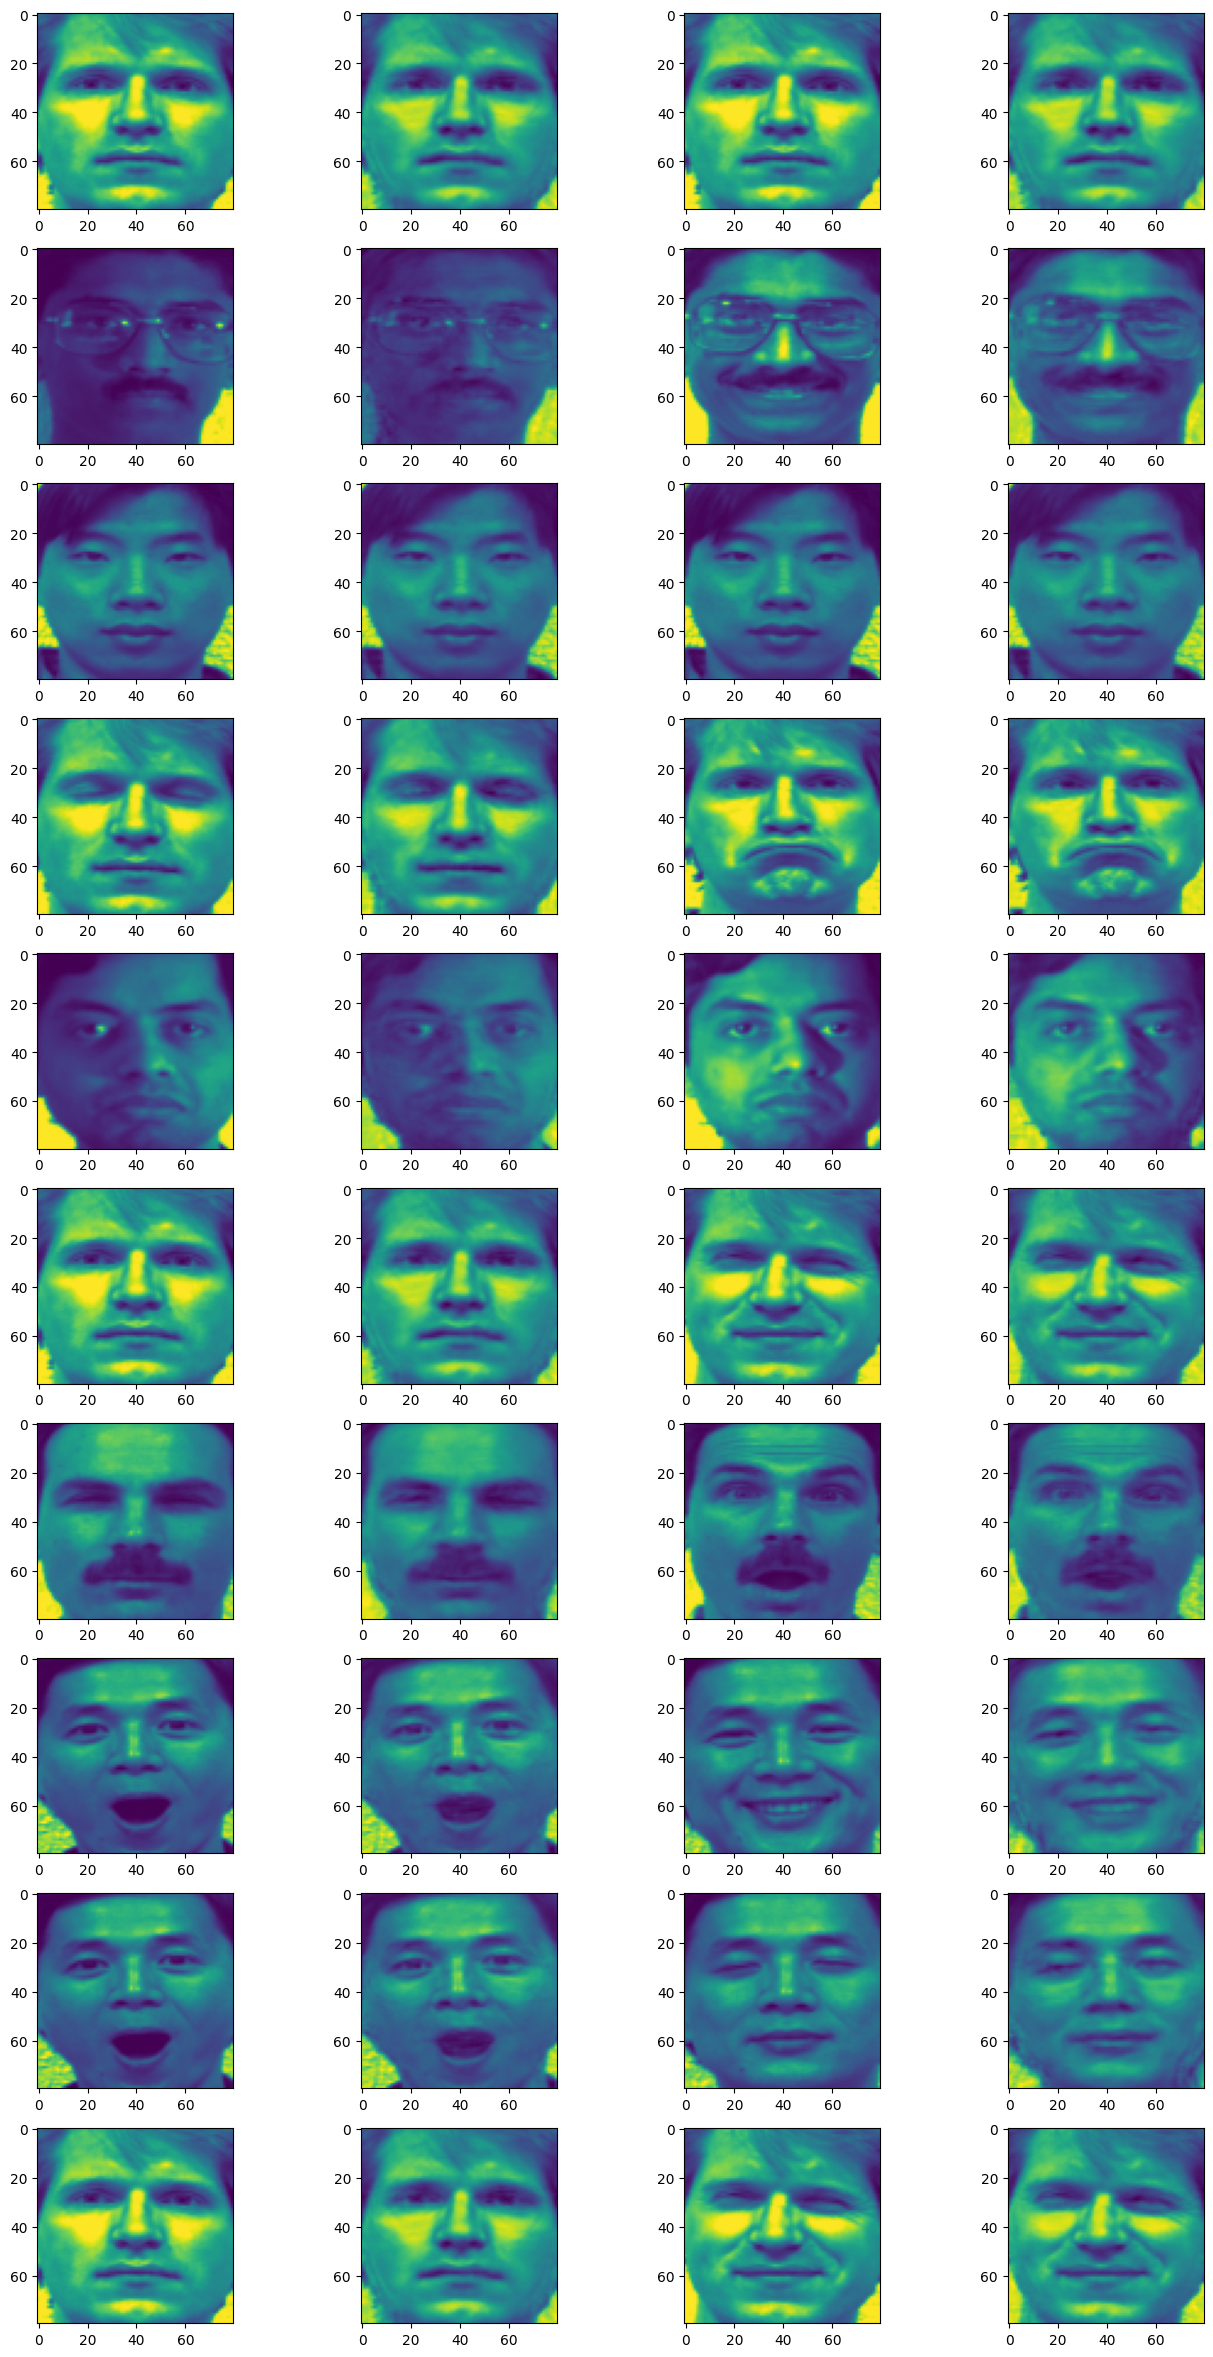

In [36]:
# Display some images
pcols = 4
prows = 10

fig = plt.figure(figsize=(16,3*prows))
for i in range(0, prows):
    subject = np.random.randint(0, 15)
    conditions = np.random.randint(0, 11, 2)

    org_img = np.reshape(T[:,subject, conditions[0]] + mT, (height, width))
    fig.add_subplot(prows, pcols, (4*i)+1)
    plt.imshow(org_img)

    rec_img = np.reshape(T_bar[:,subject, conditions[0]] + mT, (height, width))
    fig.add_subplot(prows, pcols, (4*i)+2)
    plt.imshow(rec_img)

    org_img = np.reshape(T[:,subject, conditions[1]] + mT, (height, width))
    fig.add_subplot(prows, pcols, (4*i)+3)
    plt.imshow(org_img)

    rec_img = np.reshape(T_bar[:,subject, conditions[1]] + mT, (height, width))
    fig.add_subplot(prows, pcols, (4*i)+4)
    plt.imshow(rec_img)

#### If we care less about the conditions of the image but more about the subjects, we can favor a high rank in the subject-mode and choose a low rank for the condition-mode.

In [37]:
# rank constraints
tucker_rank = [100, 15, 1]

# Tucker decomposition
core, (factors_d, factors_sub, factors_con) = tucker(T, rank=tucker_rank)

# Tensor reconstruction
T_bar = tl.tenalg.mode_dot(tl.tenalg.mode_dot(tl.tenalg.mode_dot(
    core, factors_d, 0), factors_sub, 1), factors_con, 2)


#### We can now observe that the decomposed tensor ignores the conditions while preserving the subject's appearance.

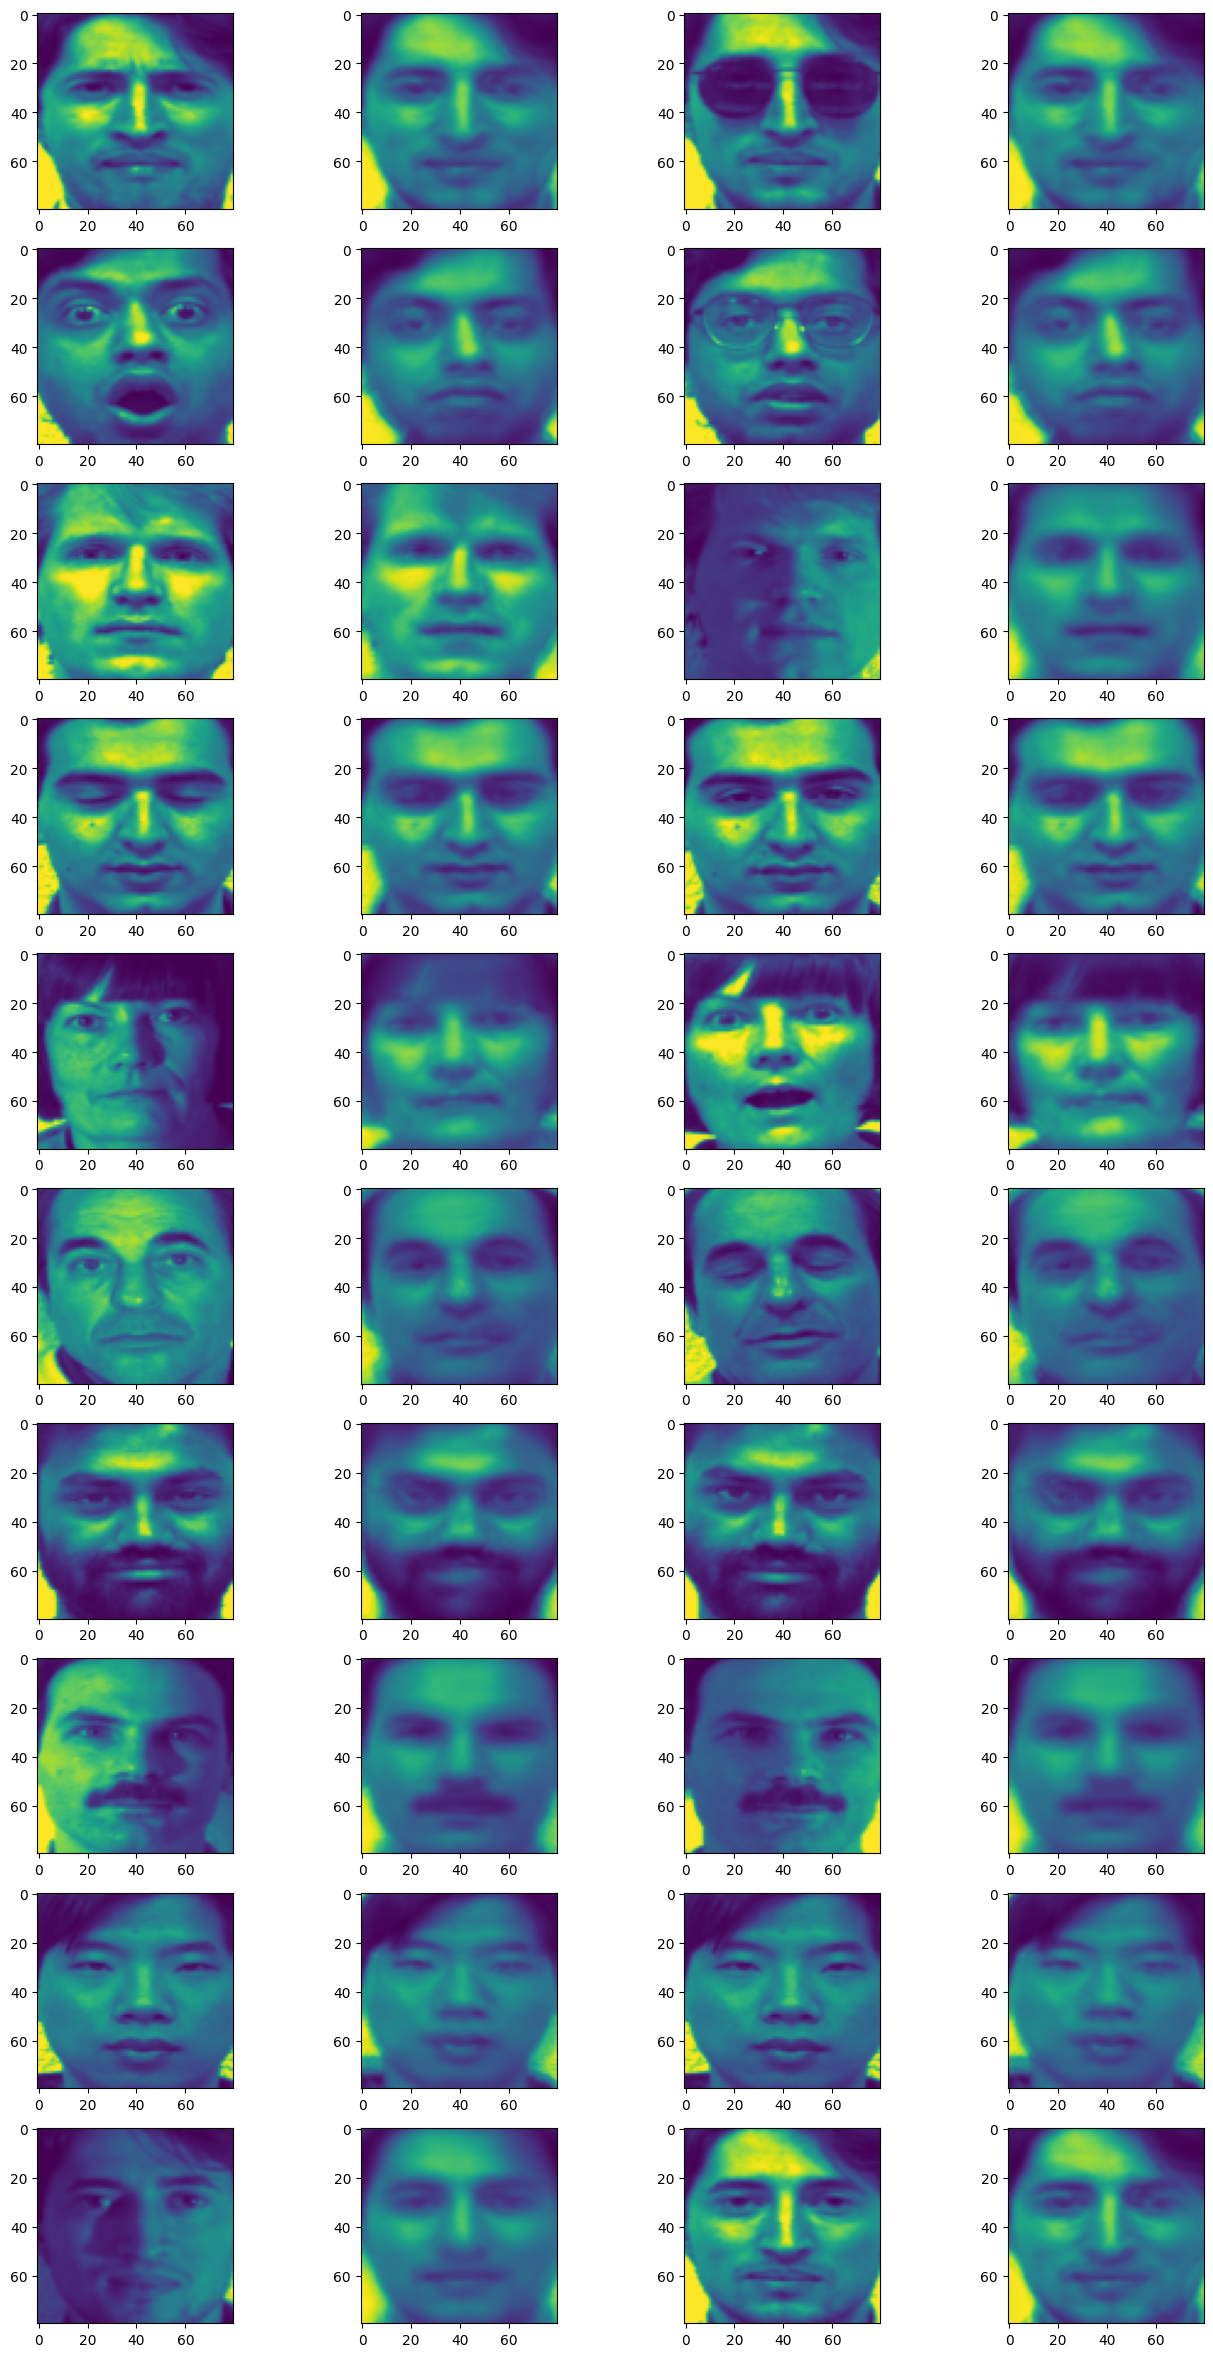

In [38]:

# Display some images
pcols = 4
prows = 10

fig = plt.figure(figsize=(16,3*prows))
for i in range(0, prows):
    subject = np.random.randint(0, 15)
    conditions = np.random.randint(0, 11, 2)

    org_img = np.reshape(T[:,subject, conditions[0]] + mT, (height, width))
    fig.add_subplot(prows, pcols, (4*i)+1)
    plt.imshow(org_img)

    rec_img = np.reshape(T_bar[:,subject, conditions[0]] + mT, (height, width))
    fig.add_subplot(prows, pcols, (4*i)+2)
    plt.imshow(rec_img)

    org_img = np.reshape(T[:,subject, conditions[1]] + mT, (height, width))
    fig.add_subplot(prows, pcols, (4*i)+3)
    plt.imshow(org_img)

    rec_img = np.reshape(T_bar[:,subject, conditions[1]] + mT, (height, width))
    fig.add_subplot(prows, pcols, (4*i)+4)
    plt.imshow(rec_img)

#### The same experiment can be performed the other way around, caring less about the subject and more about the condition.

In [39]:
# rank constraints
tucker_rank = [100, 1, 11]

# Tucker decomposition
core, (factors_d, factors_sub, factors_con) = tucker(T, rank=tucker_rank)

# Tensor reconstruction
T_bar = tl.tenalg.mode_dot(tl.tenalg.mode_dot(tl.tenalg.mode_dot(
    core, factors_d, 0), factors_sub, 1), factors_con, 2)


#### The reconstruction contains a mean face that additionally shows features resembling the condition (e.g., the mean face smiling, winking, or wearing glasses).

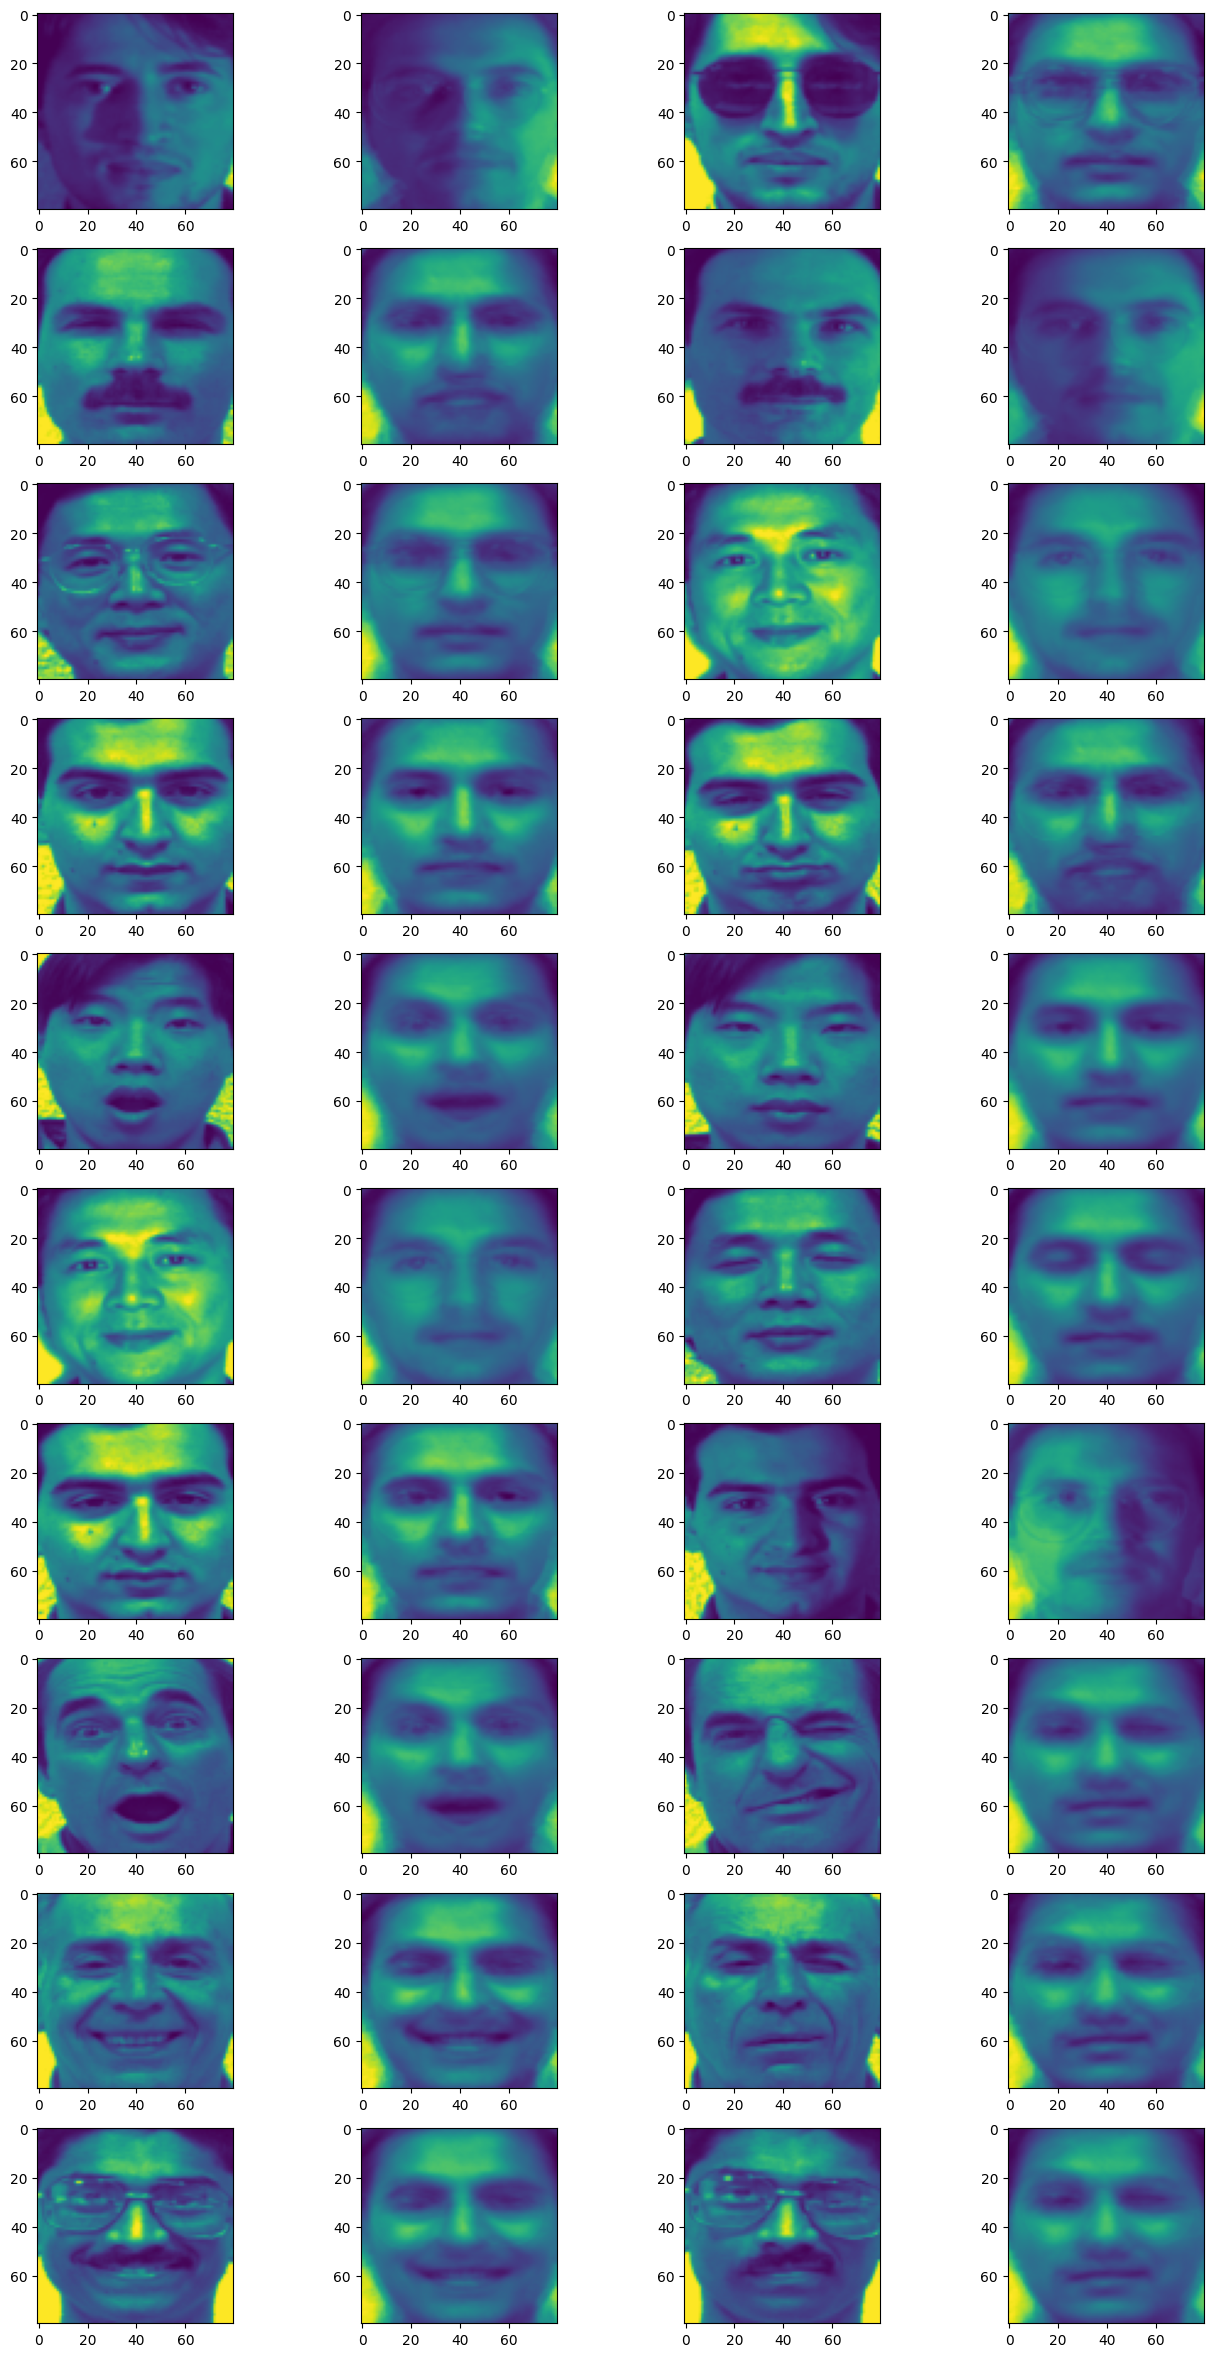

In [40]:
# Display some images
pcols = 4
prows = 10

fig = plt.figure(figsize=(16,3*prows))
for i in range(0, prows):
    subject = np.random.randint(0, 15)
    conditions = np.random.randint(0, 11, 2)

    org_img = np.reshape(T[:,subject, conditions[0]] + mT, (height, width))
    fig.add_subplot(prows, pcols, (4*i)+1)
    plt.imshow(org_img)

    rec_img = np.reshape(T_bar[:,subject, conditions[0]] + mT, (height, width))
    fig.add_subplot(prows, pcols, (4*i)+2)
    plt.imshow(rec_img)

    org_img = np.reshape(T[:,subject, conditions[1]] + mT, (height, width))
    fig.add_subplot(prows, pcols, (4*i)+3)
    plt.imshow(org_img)

    rec_img = np.reshape(T_bar[:,subject, conditions[1]] + mT, (height, width))
    fig.add_subplot(prows, pcols, (4*i)+4)
    plt.imshow(rec_img)